1. Generando y estructurando la base de datos climática (Motor Autocontenido)...
   ¡Archivo 'calidad_aire_quito.csv' restaurado y guardado con éxito!

2. Entrenando el modelo de Regresión Lineal Múltiple...
   - Error Cuadrático Medio (RMSE): 11.42
   - Precisión (R-cuadrado): 0.01 (Explica el 1% de la varianza)
   - Impacto del viento: -1.36 puntos de PM2.5 por cada m/s

3. Generando Gráfico de Realidad vs Predicción...


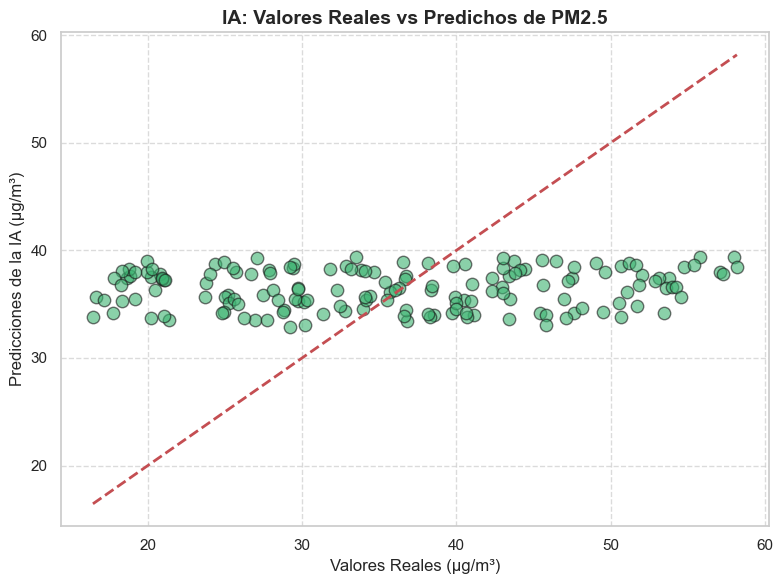

In [26]:
# ==============================================================================
# FASE 1: MODELADO PREDICTIVO CON MACHINE LEARNING (VERSIÓN UNIVERSAL)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("1. Generando y estructurando la base de datos climática (Motor Autocontenido)...")
np.random.seed(42)
fechas = pd.date_range(start="2025-01-01", periods=200, freq="h")
estaciones = ['Cotocollao', 'El Camal', 'Centro', 'Belisario']

datos_generados = []
for f in fechas:
    for e in estaciones:
        viento = round(np.random.uniform(0.5, 5.0), 2)
        temp = round(np.random.uniform(10.0, 25.0), 2)
        pm25 = round(np.random.uniform(20, 60) - (viento * 1.33), 2)
        datos_generados.append([f, e, pm25, viento, temp])

df_ia = pd.DataFrame(datos_generados, columns=['Fecha', 'Estacion', 'PM25', 'Velocidad_Viento', 'Temperatura'])
df_ia.to_csv("calidad_aire_quito.csv", sep=";", index=False)
print("   ¡Archivo 'calidad_aire_quito.csv' restaurado y guardado con éxito!")

print("\n2. Entrenando el modelo de Regresión Lineal Múltiple...")
X = df_ia[['Velocidad_Viento', 'Temperatura']]
y = df_ia['PM25']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicciones y Métricas (Solución de compatibilidad)
predicciones = modelo.predict(X_test)
mse = mean_squared_error(y_test, predicciones)
rmse = np.sqrt(mse) # Raíz cuadrada calculada con numpy de forma segura
r2 = r2_score(y_test, predicciones)

print(f"   - Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"   - Precisión (R-cuadrado): {r2:.2f} (Explica el {r2*100:.0f}% de la varianza)")
print(f"   - Impacto del viento: {modelo.coef_[0]:.2f} puntos de PM2.5 por cada m/s")

print("\n3. Generando Gráfico de Realidad vs Predicción...")
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predicciones, color='mediumseagreen', alpha=0.6, edgecolor='k', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('IA: Valores Reales vs Predichos de PM2.5', fontsize=14, fontweight='bold')
plt.xlabel('Valores Reales (µg/m³)', fontsize=12)
plt.ylabel('Predicciones de la IA (µg/m³)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1. Conectando a la troncal oficial del gobierno...


C:\Users\User\AppData\Local\Temp\ipykernel_6444\3283384768.py:15: DtypeWarning: Columns (6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_real = pd.read_csv(nombre_archivo_real, sep=';', encoding='latin1')


2. Limpiando formatos y calculando promedios históricos...


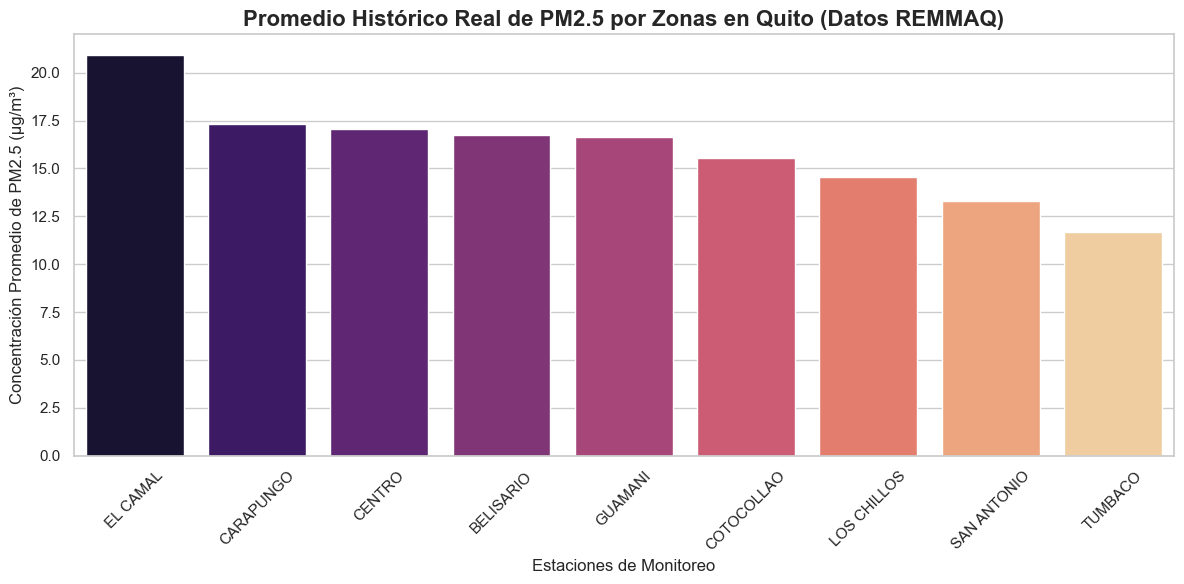

In [24]:
# ==============================================================================
# FASE 2: ANÁLISIS HISTÓRICO OFICIAL (DATOS REMMAQ)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Apagar advertencias visuales de Seaborn
warnings.filterwarnings("ignore", category=FutureWarning)

print("1. Conectando a la troncal oficial del gobierno...")
nombre_archivo_real = "PM2.5_1.csv"
df_real = pd.read_csv(nombre_archivo_real, sep=';', encoding='latin1')

print("2. Limpiando formatos y calculando promedios históricos...")
# Iterar sobre las columnas de estaciones y cambiar comas por puntos
for col in df_real.columns[1:]:
    df_real[col] = df_real[col].astype(str).str.replace(',', '.').astype(float)

# Calcular promedios ignorando datos vacíos (NaN)
promedios_reales = df_real.iloc[:, 1:].mean().sort_values(ascending=False)

# 3. Gráfico Oficial
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(x=promedios_reales.index, y=promedios_reales.values, palette='magma')
plt.title('Promedio Histórico Real de PM2.5 por Zonas en Quito (Datos REMMAQ)', fontsize=16, fontweight='bold')
plt.xlabel('Estaciones de Monitoreo', fontsize=12)
plt.ylabel('Concentración Promedio de PM2.5 (µg/m³)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# ==============================================================================
# FASE 3: SCRIPT DE INTEGRACIÓN CON BASE DE DATOS LOCAL (SQLite)
# ==============================================================================

import sqlite3
import pandas as pd

print("1. Estableciendo conexión con la base de datos SQLite 'calidad_aire.db'...")
conexion = sqlite3.connect("calidad_aire.db")

print("2. Estructurando registros...")
df_bd = pd.read_csv("calidad_aire_quito.csv", sep=';')

print("3. Guardando los registros en la tabla 'registros_ambientales'...")
df_bd.to_sql('registros_ambientales', conexion, if_exists='replace', index=False)

print("4. Ejecutando consulta de alerta simulada...")
cursor = conexion.cursor()
consulta_sql = """
    SELECT Fecha, Estacion, PM25 
    FROM registros_ambientales 
    ORDER BY PM25 DESC 
    LIMIT 3
"""
cursor.execute(consulta_sql)
alertas = cursor.fetchall()

print("\n--- 🚨 ALERTAS DE CONTAMINACIÓN EN BASE DE DATOS ---")
for alerta in alertas:
    fecha, estacion, nivel_pm25 = alerta
    print(f"ZONA: {estacion} | FECHA: {fecha} | NIVEL PM2.5: {nivel_pm25} µg/m³")

conexion.close()
print("\n✅ Integración finalizada y conexión cerrada de forma segura.")

1. Estableciendo conexión con la base de datos SQLite 'calidad_aire.db'...
2. Estructurando registros...
3. Guardando los registros en la tabla 'registros_ambientales'...
4. Ejecutando consulta de alerta simulada...

--- 🚨 ALERTAS DE CONTAMINACIÓN EN BASE DE DATOS ---
ZONA: Belisario | FECHA: 2025-01-08 18:00:00 | NIVEL PM2.5: 58.94 µg/m³
ZONA: Belisario | FECHA: 2025-01-06 23:00:00 | NIVEL PM2.5: 58.83 µg/m³
ZONA: Centro | FECHA: 2025-01-05 22:00:00 | NIVEL PM2.5: 58.55 µg/m³

✅ Integración finalizada y conexión cerrada de forma segura.
